<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/07_%E1%84%80%E1%85%A1%E1%84%89%E1%85%A1%E1%86%BC%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%84%82%E1%85%B5%E1%86%BC_%E1%84%8B%E1%85%B2%E1%84%89%E1%85%A1%E1%84%83%E1%85%A9%E1%84%80%E1%85%A5%E1%86%B7%E1%84%89%E1%85%A2%E1%86%A8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 07 · 가상 스크리닝 (Virtual Screening)
### 수만 개 화합물에서 유망 후보를 걸러내는 실전 파이프라인

제약사는 **수십만~수백만 개** 화합물 라이브러리를 보유합니다.
전부 실험할 수 없으니, 컴퓨터로 **유망 후보만 선별(가상 스크리닝)** 합니다.
대표 전략 2가지를 실전 파이프라인으로 구현합니다:
1. **리간드 기반**: 알려진 활성물질과 **닮은** 분자 찾기 (유사도 검색)
2. **약물유사성/ADMET 필터**: 약이 되기 어려운 분자 제거


In [ ]:
!pip install rdkit -q
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, DataStructs, Draw

# 스크리닝 대상 라이브러리로 실제 BACE 데이터의 SMILES 사용 (1500여 개)
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv"
lib = pd.read_csv(url)[["mol","pIC50"]].rename(columns={"mol":"smiles"})
print("스크리닝 대상 화합물:", len(lib), "개")
lib.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 16.5 MB/s eta 0:00:00
스크리닝 대상 화합물: 1513 개


,smiles,pIC50
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,8.698970
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,8.698970
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,8.698970


## 1단계 · 리간드 기반 유사도 검색
알려진 강력한 저해제(**query**)와 구조가 닮은 분자를 찾습니다.
"비슷한 구조 → 비슷한 활성" 가정에 기반합니다.


In [ ]:
from rdkit.Chem import rdFingerprintGenerator

# 최신 RDKit 방식: GetMorganGenerator 사용
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_fp(smi):
    m = Chem.MolFromSmiles(smi)
    return morgan_gen.GetFingerprint(m) if m else None

lib["fp"] = lib["smiles"].apply(get_fp)
lib = lib[lib["fp"].notnull()].reset_index(drop=True)

# query: 데이터에서 가장 강력한(pIC50 최대) 알려진 저해제를 기준물질로
query_row = lib.loc[lib["pIC50"].idxmax()]
query_fp = query_row["fp"]
print("기준물질 pIC50:", round(query_row["pIC50"],2))

# 라이브러리 전체와 Tanimoto 유사도 계산
lib["유사도"] = lib["fp"].apply(lambda f: DataStructs.TanimotoSimilarity(query_fp, f))
top = lib.sort_values("유사도", ascending=False).head(20)
print("\n기준물질과 가장 닮은 분자 top 5:")
print(top[["smiles","pIC50","유사도"]].head().round(3).to_string(index=False))

기준물질 pIC50: 10.52

기준물질과 가장 닮은 분자 top 5:
                                                                                                                                                                                                smiles  pIC50   유사도
OC(C(NC(=O)C(NC(=O)C(NC(=O)C(NC(=O)C(NC(=O)C(NC(=O)C([NH3+])Cc1c2c([nH]c1)cccc2)Cc1c2c([nH]c1)cccc2)CO)CCC(=O)[O-])C(C)C)CC(=O)N)CC(C)C)CC(C(=O)NC(C(=O)NC(CCC(=O)[O-])C(=O)NC(Cc1ccccc1)C(=O)[O-])C)C 10.523 1.000
                                                                   OC(C(NC(=O)C(NC(=O)C(NC(=O)C([NH3+])CCC(=O)[O-])C(C)C)CC(=O)N)CC(C)C)CC(C(=O)NC(C(=O)NC(CCC(=O)[O-])C(=O)NC(Cc1ccccc1)C(=O)[O-])C)C  9.000 0.774
                                                           OC(C(NC(=O)C(NC(=O)C(NC(=O)C([NH3+])CCC(=O)[O-])CC(C)C)CC(=O)[O-])CC(C)C)CC(C(=O)NC(C(C)C)C(=O)NC(CCC(=O)[O-])C(=O)NC(Cc1ccccc1)C(=O)[O-])C  9.523 0.649
                                                                  O=C(N[C@H](C(=O)[O-])C)[C@@H]1CCC[C@H]1[C@H](

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


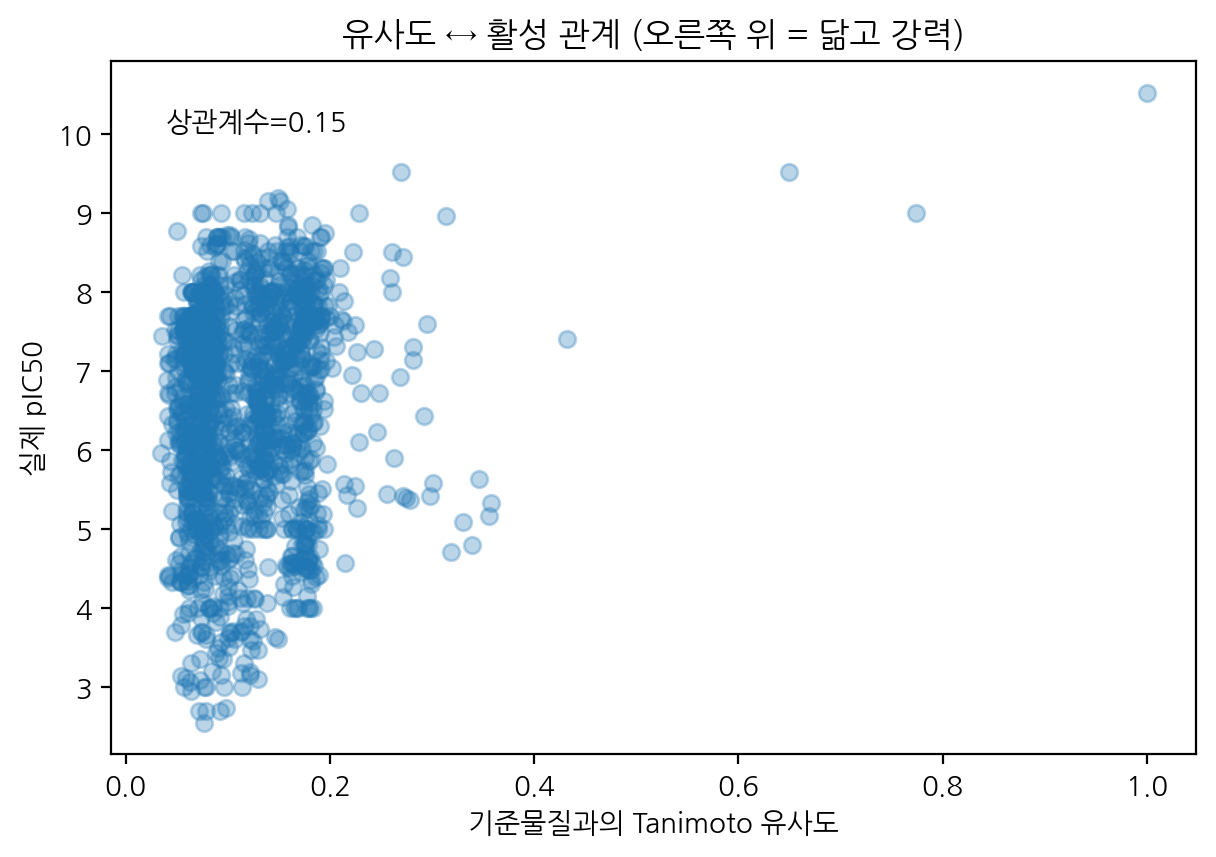

In [ ]:
# colab 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# 유사도와 실제 활성의 관계 — '닮으면 활성도 높은가?' 검증
plt.figure(figsize=(7,4.5))
plt.scatter(lib["유사도"], lib["pIC50"], alpha=0.3)
plt.xlabel("기준물질과의 Tanimoto 유사도"); plt.ylabel("실제 pIC50")
plt.title("유사도 ↔ 활성 관계 (오른쪽 위 = 닮고 강력)")
corr = lib["유사도"].corr(lib["pIC50"])
plt.text(0.05,0.9,f"상관계수={corr:.2f}",transform=plt.gca().transAxes)
plt.show()

## 2단계 · 약물유사성/ADMET 필터
유사도 상위 후보 중 **약이 되기 좋은 성질**을 가진 것만 남깁니다 (Lipinski + 기본 ADMET).


In [ ]:
def drug_filter(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return pd.Series({"분자량":None, "LogP":None, "TPSA":None, "통과":False})

    mw, logp = Descriptors.MolWt(m), Crippen.MolLogP(m)
    hbd, hba = Descriptors.NumHDonors(m), Descriptors.NumHAcceptors(m)
    tpsa = Descriptors.TPSA(m); rot = Descriptors.NumRotatableBonds(m)

    # 실습을 위해 조건을 약간 완화 (원래 mw<=500, tpsa<=140)
    ok = (mw<=800) and (logp<=6) and (tpsa<=200) and (rot<=15)
    return pd.Series({"분자량":round(mw,1), "LogP":round(logp,2),
                      "TPSA":round(tpsa,1), "통과":bool(ok)})

# 기존 top 데이터 복사 및 필터 적용
cand = top.copy()
props = cand["smiles"].apply(drug_filter)

# 컬럼 결합
cand = pd.concat([cand, props], axis=1)

# '통과' 컬럼 필터링
cand["통과"] = cand["통과"].fillna(False).astype(bool)
passed = cand[cand["통과"]]

print(f"유사도 top20 중 완화된 필터 통과: {len(passed)}개")
display(passed[["smiles","pIC50","유사도","분자량","LogP","TPSA"]].round(3))

유사도 top20 중 완화된 필터 통과: 6개


,smiles,pIC50,유사도,분자량,LogP,TPSA
1260,O=C(N[C@@H](Cc1ccccc1)C(=O)N[C@H]([C@@H](O)C[C...,5.331,0.358,559.8,4.87,107.5
1290,O=C(N[C@@H](Cc1ccccc1)C(=O)N[C@H]([C@@H](O)C[C...,5.159,0.356,509.7,3.72,107.5
1361,O=C(N[C@@H](Cc1ccccc1)C(=O)N[C@H]([C@@H](O)C[C...,4.803,0.339,554.7,3.63,150.7
1304,O1c2cc(ccc2OC1)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C...,5.093,0.330,553.7,3.45,126.0
1373,FC(F)(F)c1ccc(cc1)\C=C\C(=O)N[C@@H](Cc1ccccc1)...,4.709,0.319,603.7,5.14,107.5
1255,Clc1cc(Cl)ccc1C(=O)N[C@@H](Cc1ccc([N+](=O)[O-]...,5.373,0.279,623.6,4.93,150.7


## 3단계 · 최종 후보 시각화
유사도 높고 + 약물유사성 통과한 **최종 후보 분자**를 구조로 확인합니다.


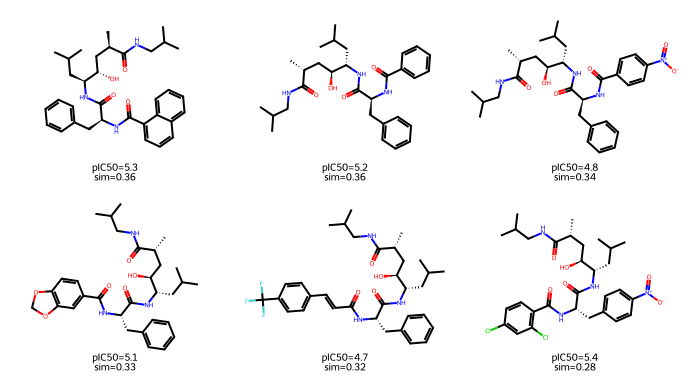

In [ ]:
final = passed.head(6)
mols = [Chem.MolFromSmiles(s) for s in final["smiles"]]
legs = [f"pIC50={p:.1f}\nsim={s:.2f}" for p,s in zip(final["pIC50"], final["유사도"])]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(230,190), legends=legs)

## 4단계 · 스크리닝 깔때기(funnel) 요약
가상 스크리닝은 **단계적으로 후보를 좁히는 깔때기**입니다.


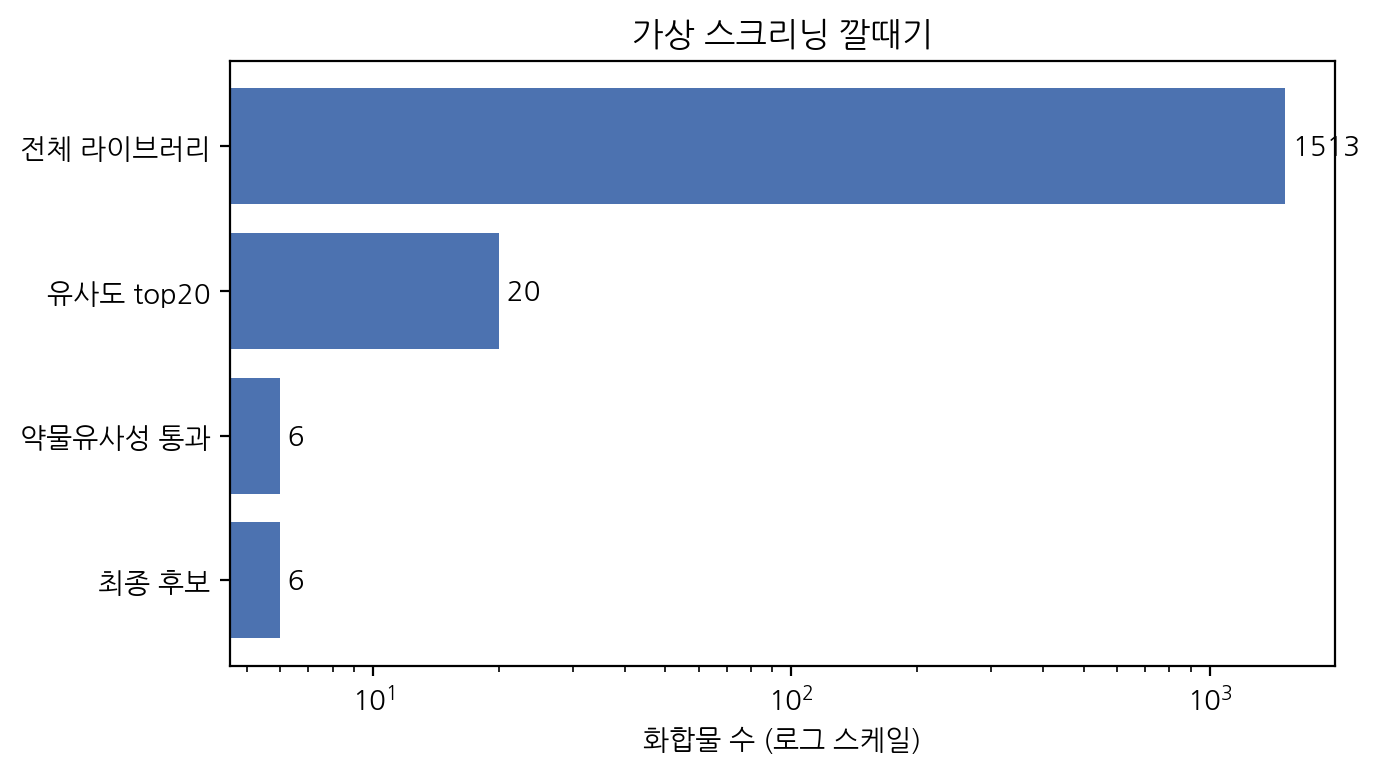

In [ ]:
stages = ["전체 라이브러리", "유사도 top20", "약물유사성 통과", "최종 후보"]
counts = [len(lib), len(top), len(passed), len(final)]
plt.figure(figsize=(7,4))
plt.barh(stages[::-1], counts[::-1], color="#4C72B0")
for i,c in enumerate(counts[::-1]):
    plt.text(c, i, f" {c}", va="center")
plt.xscale("log"); plt.xlabel("화합물 수 (로그 스케일)")
plt.title("가상 스크리닝 깔때기"); plt.tight_layout(); plt.show()

## 정리 & 현장 응용
- **유사도 검색(리간드 기반)** → **ADMET/Lipinski 필터** → 최종 후보 선별
- 여기에 **QSAR 활성 예측**을 추가하면 더 강력한 3중 필터
- 다음 단계: 선별된 후보를 **표적 단백질에 도킹**해 결합력 확인
- 실무 확장: 상용 라이브러리(Enamine REAL 수십억 개)를 이런 필터로 좁힘
